# BNS-only MCMC → analytical BNS + NSBH grid

This notebook runs the corrected two-stage comparison:

1. Fit a five-parameter **BNS-only MCMC** over $A$, $\log_{10}(L_0)$, $\mu_{E,p}$, $\sigma_{E,p}$, and $\theta_c^{\rm BNS}$.
2. Select the maximum-posterior BNS sample, optionally subject to $A<3$.
3. Fix $A$, $\mu_{E,p}$, and $\sigma_{E,p}$ at that sample.
4. Evaluate the remaining four-parameter **BNS + NSBH likelihood explicitly on a grid** over $\log_{10}(L_0)$, $\log_{10}(\kappa_{\rm NSBH})$, $\theta_c^{\rm BNS}$, and $\theta_c^{\rm NSBH}$.

Stage 2 is not an MCMC. The observable-shape likelihood is evaluated on the two luminosity axes and the Poisson likelihood is broadcast over the two opening-angle axes, retaining the fast factorization from `mcmc_runner_a.py`.

In [62]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, '../../..')
sys.path.insert(0, '../..')
sys.path.insert(0, '.')

style_path = Path('../../../configurations/style.mplstyle')
if style_path.is_file():
    plt.style.use(style_path)

from mcmc_runner_single import (
    N_PARAMS_SINGLE,
    collect_rate_posteriors,
    draw_grid_samples,
    extract_bns_best_fits,
    full_backend_path,
    plot_bns_corners,
    plot_corner_grid_multiples,
    plot_grid_vs_full,
    plot_posterior_grid,
    run_pop,
    run_pop_combined,
    summarize_grid_vs_full,
)
from src.top_hat.geometric_eff import geometric_efficiency_flat_midpoint

print(f'The BNS-only stage samples {N_PARAMS_SINGLE} parameters.')
print('The combined stage evaluates a four-dimensional grid (no MCMC).')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The BNS-only stage samples 5 parameters.
The combined stage evaluates a four-dimensional grid (no MCMC).


## Configuration

For a controlled comparison, keep the population, jet fraction, geometry prescription, Monte Carlo population size, and seed aligned with the fully joint run. Increasing the four `N_*` grid values improves resolution but increases the size of the saved 4D tensors.

In [77]:
DATAFILES = Path('../../../datafiles')
IMAGES_FOLDER = Path('Images/single_likelihood')
IMAGES_FOLDER.mkdir(parents=True, exist_ok=True)

POSSIBLE_ALPHA  = ['A3.0', 'A5.0']
FJ_BNS          = 1.0 #1.0 or 0.1
POPULATION      = 'qcbse'
NSBH_SERIES     = [
    'NSBH_DD2_uniform_chi_0_1',
    'NSBH_SFHo_uniform_chi_0_1',
]
SERIES_LABELS   = {
    'NSBH_DD2_uniform_chi_0_1': r'DD2, $\chi\sim\mathcal{U}(0,1)$',
    'NSBH_SFHo_uniform_chi_0_1': r'SFHo, $\chi\sim\mathcal{U}(0,1)$',
}
REFERENCE_NSBH_SERIES   = NSBH_SERIES[0]
GEOM_EFF_FUNC           = geometric_efficiency_flat_midpoint
SEED                    = 123

# Stage 1: BNS-only MCMC
N_WALKERS_BNS   = 24
N_STEPS_BNS     = 10_000
BNS_N_EVENTS    = None  # None uses mcmc_runner_single.N_MC_EVENTS
BNS_DISCARD     = None    # Set None to use BURN_FRAC instead
BURN_FRAC       = 0.33
THIN            = 10
MAX_A_INDEX     = 6

# Stage 2: explicit four-dimensional grid
N_L0            = 50
N_K             = 40
N_THETA_BNS     = 80
N_THETA_NSBH    = 80
L0_BOUNDS       = (-2.0, 7.0)
K_BOUNDS            = (-2.0, 0.0)
THETA_BNS_BOUNDS    = (1.0, 25.0)
THETA_NSBH_BOUNDS   = (1.0, 25.0)
GRID_N_EVENTS       = None  # None uses 2 * mcmc_runner_single.N_MC_EVENTS

# Only used to visualize/integrate the already-computed grid.
N_GRID_DRAWS = 40_000

## Check the population files

In [78]:
MRD_FOLDER = DATAFILES / 'MRD_outputs'
required_mrd_files = set()

for alpha in POSSIBLE_ALPHA:
    alpha_file = alpha.replace('.', '_')
    required_mrd_files.add(MRD_FOLDER / f'{POPULATION}_{alpha_file}_BNS.csv')
    for nsbh_series in NSBH_SERIES:
        required_mrd_files.add(
            MRD_FOLDER / f'{POPULATION}_{alpha_file}_{nsbh_series}.csv'
        )

missing_mrd_files = [
    path for path in sorted(required_mrd_files) if not path.is_file()
]
if missing_mrd_files:
    raise FileNotFoundError(
        'The following MRD files are missing:\n'
        + '\n'.join(str(path) for path in missing_mrd_files)
    )

print(f'Found all {len(required_mrd_files)} required MRD files.')


Found all 6 required MRD files.


## Stage 1 — run or resume the BNS-only MCMC

The BNS-only backend has its own run name and cannot collide with a fully joint backend. `REFERENCE_NSBH_SERIES` is passed only because the combined population initializer requires it; NSBH quantities do not enter this likelihood.

In [79]:
bns_kwargs = {
    'alphas'        : POSSIBLE_ALPHA,
    'fj_bns'        : FJ_BNS,
    'geom_eff_func' : GEOM_EFF_FUNC,
    'datafiles'     : DATAFILES,
    'population'    : POPULATION,
    'nsbh_series'   : REFERENCE_NSBH_SERIES,
    'n_walkers'     : N_WALKERS_BNS,
    'n_steps'       : N_STEPS_BNS,
    'seed'          : SEED,
}
if BNS_N_EVENTS is not None:
    bns_kwargs['n_events'] = BNS_N_EVENTS

bns_path_list = run_pop(**bns_kwargs)
bns_backend_paths = dict(zip(POSSIBLE_ALPHA, bns_path_list))
bns_backend_paths

Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
BNS: R(z=0.01)=34.05 Gpc^-3 yr^-1; all-sky rate=2.616e+04 yr^-1; MC sample=10000
NSBH_DD2_uniform_chi_0_1: R(z=0.01)=5.06 Gpc^-3 yr^-1; all-sky rate=7.750e+03 yr^-1; MC sample=10000
Loading existing directory  : Output_files/bns_only_alpha_A3.0_fj_1_geometric-efficiency-flat-midpoint_qcbse
Already completed this run
stage=BNS-only; alpha=A3.0; fj_bns=1; geometry=geometric-efficiency-flat-midpoint; population=qcbse; remaining steps=0
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
BNS: R(z=0.01)=9.52 Gpc^-3 yr^-1; all-sky rate=2.106e+04 yr^-1; MC sample=10000
NSBH_DD2_uniform_chi_0_1: R(z=0.01)=4.59 Gpc^-3 yr^-1; all-sky rate=6.426e+03 yr^-1; MC sample=10000
Loading existing directo

{'A3.0': PosixPath('Output_files/bns_only_alpha_A3.0_fj_1_geometric-efficiency-flat-midpoint_qcbse/emcee.h5'),
 'A5.0': PosixPath('Output_files/bns_only_alpha_A5.0_fj_1_geometric-efficiency-flat-midpoint_qcbse/emcee.h5')}

## Select the maximum-posterior BNS samples

This reproduces the supplied `A_index < 3` selection while keeping flattened samples and log probabilities exactly aligned. The combined grid uses only `A_index`, `L_mu_E`, and `sigma_E`; the other selected values are retained for diagnostics.

In [80]:
bns_best_fits = extract_bns_best_fits(
    bns_backend_paths,
    discard=BNS_DISCARD,
    burn_frac=BURN_FRAC,
    thin=THIN,
    max_a_index=MAX_A_INDEX,
)

fixed_params = {
    alpha: {
        'A_index': values['A_index'],
        'L_mu_E': values['L_mu_E'],
        'sigma_E': values['sigma_E'],
    }
    for alpha, values in bns_best_fits.items()
}
fixed_params


alpha=A3.0, A_index < 6: log_prob=-3.913, A=4.889, L0=2.528, mu_E=3.143, sigma_E=0.337, theta_BNS=14.572
alpha=A5.0, A_index < 6: log_prob=-3.896, A=4.568, L0=3.521, mu_E=3.245, sigma_E=0.332, theta_BNS=7.509


{'A3.0': {'A_index': 4.8891027335735515,
  'L_mu_E': 3.1428170350548625,
  'sigma_E': 0.33699309884005435},
 'A5.0': {'A_index': 4.568112515406475,
  'L_mu_E': 3.2450624135895367,
  'sigma_E': 0.3322225177333195}}

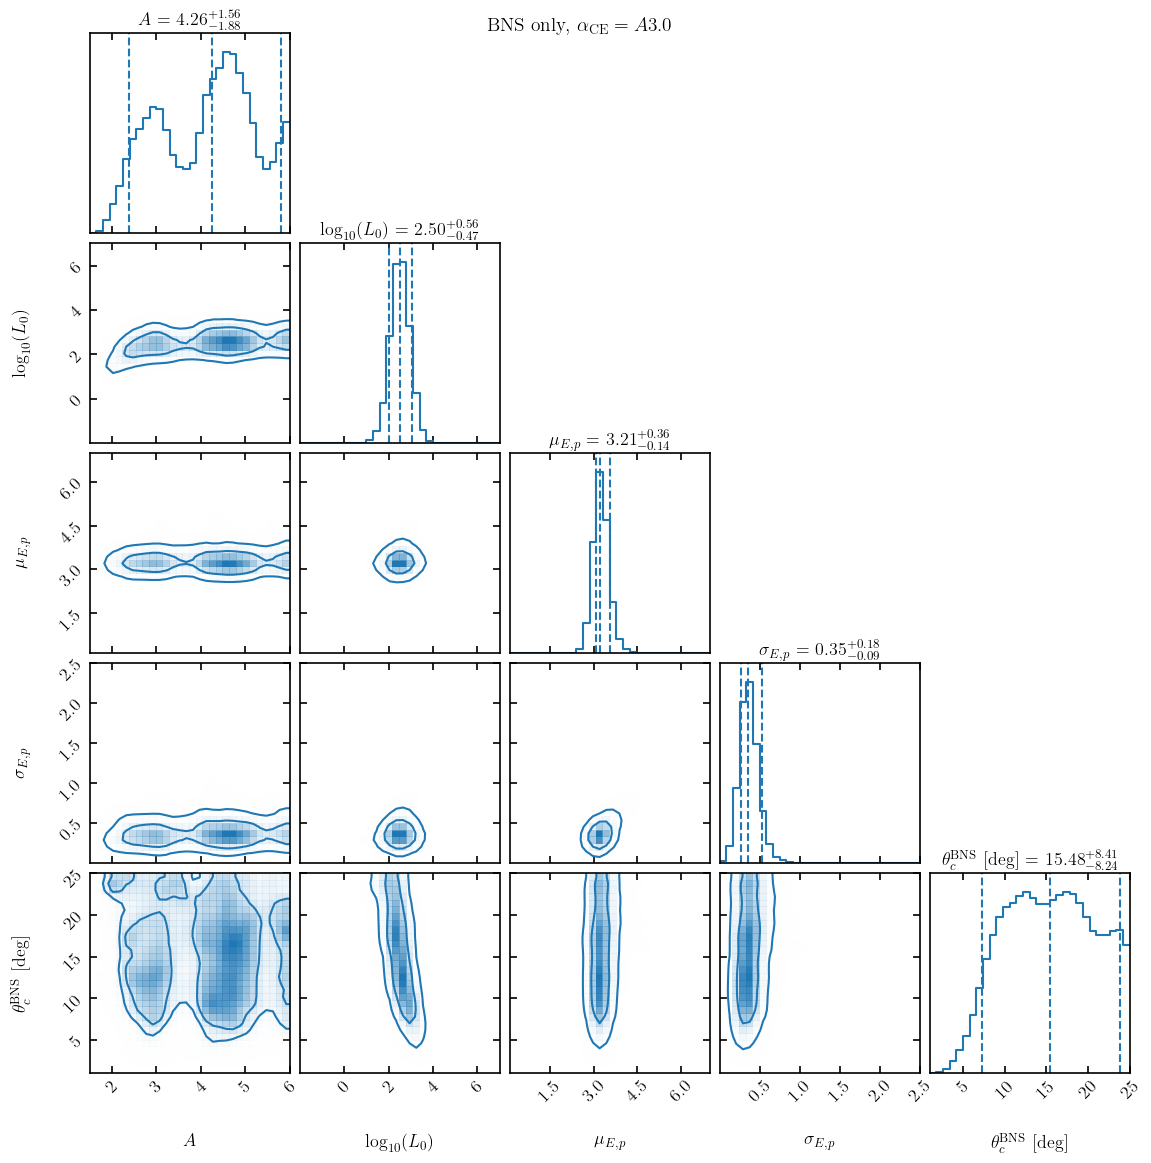

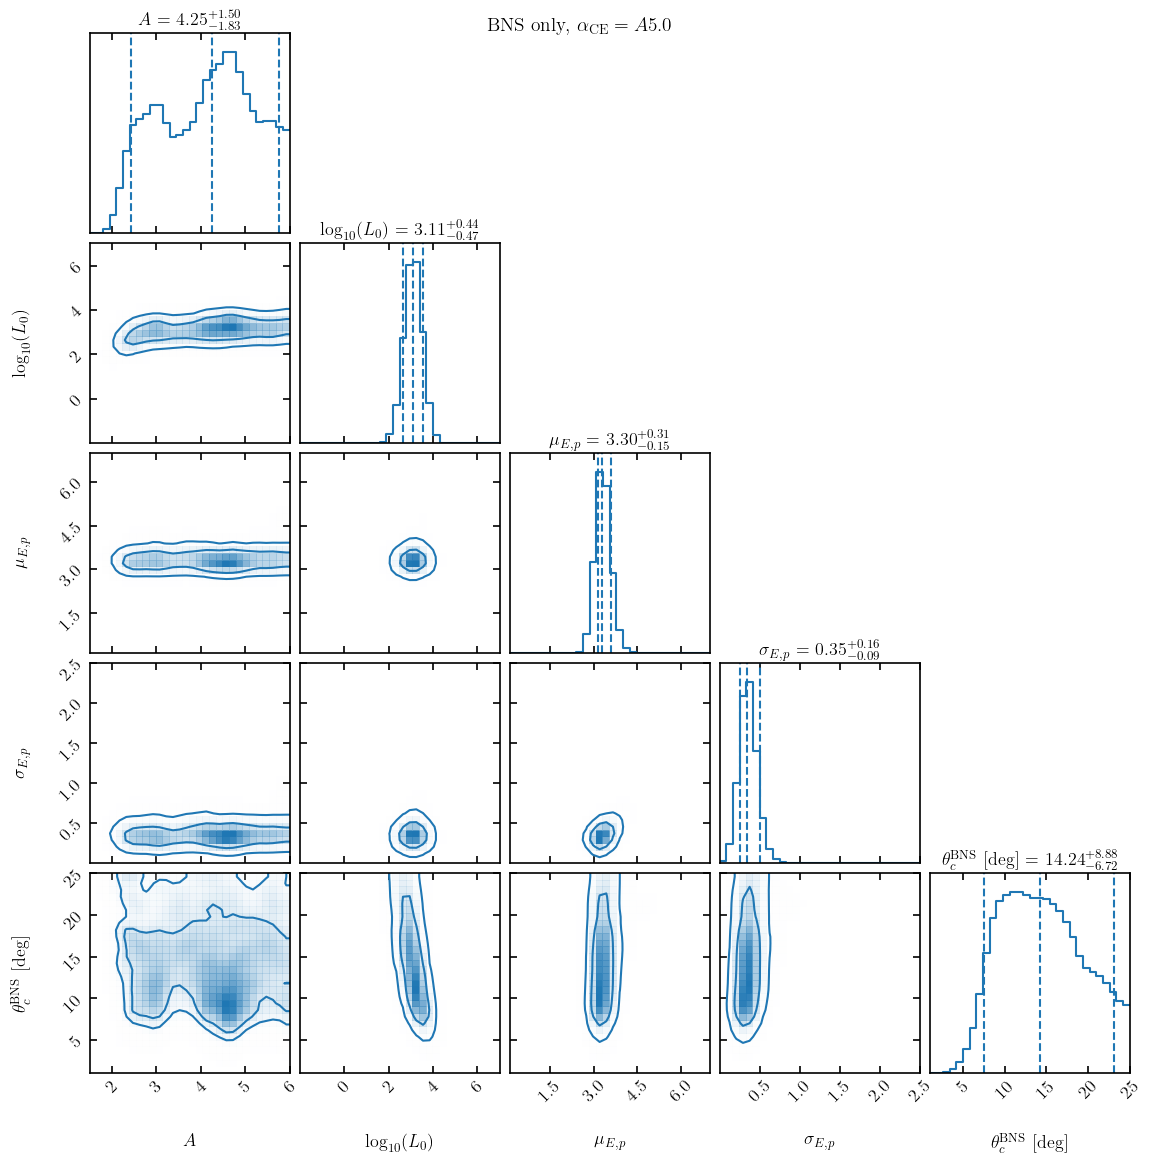

In [81]:
bns_figures = plot_bns_corners(
    bns_backend_paths,
    discard=BNS_DISCARD,
    burn_frac=BURN_FRAC,
    thin=THIN,
)
for alpha, fig in bns_figures.items():
    fig.savefig(
        IMAGES_FOLDER / f'bns_only_corner_{POPULATION}_{alpha}.pdf',
        bbox_inches='tight',
    )
    plt.show()

## Stage 2 — evaluate the analytical BNS + NSBH grids

Each call writes one compressed 4D tensor per $\alpha_{\rm CE}$. The run name includes a fingerprint of the fixed BNS values, so changing the stage-1 best fit produces a distinct grid.

In [82]:
grid_paths_by_series = {}
local_rate_dicts = {}

for nsbh_series in NSBH_SERIES:
    grid_kwargs = {
        'alphas': POSSIBLE_ALPHA,
        'geom_eff_func': GEOM_EFF_FUNC,
        'datafiles': DATAFILES,
        'fixed_params': fixed_params,
        'nsbh_series': nsbh_series,
        'population': POPULATION,
        'FJ_BNS': FJ_BNS,
        'n_l0': N_L0,
        'n_k': N_K,
        'n_tbns': N_THETA_BNS,
        'n_tnsbh': N_THETA_NSBH,
        'l0_bounds': L0_BOUNDS,
        'k_bounds': K_BOUNDS,
        'theta_bns_bounds': THETA_BNS_BOUNDS,
        'theta_nsbh_bounds': THETA_NSBH_BOUNDS,
        'seed': SEED,
    }
    if GRID_N_EVENTS is not None:
        grid_kwargs['n_events'] = GRID_N_EVENTS

    grid_path_list, local_rates = run_pop_combined(**grid_kwargs)
    grid_paths_by_series[nsbh_series] = dict(
        zip(POSSIBLE_ALPHA, grid_path_list)
    )
    local_rate_dicts[nsbh_series] = local_rates

grid_paths_by_series

Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
BNS: R(z=0.01)=34.05 Gpc^-3 yr^-1; all-sky rate=2.616e+04 yr^-1; MC sample=20000
NSBH_DD2_uniform_chi_0_1: R(z=0.01)=5.06 Gpc^-3 yr^-1; all-sky rate=7.750e+03 yr^-1; MC sample=20000
stage=analytical-grid; alpha=A3.0; observable cells=2000; angle cells=6400
Loading existing directory  : Output_files/analytical_joint_alpha_A3.0_fj_1_geometric-efficiency-flat-midpoint_qcbse_NSBH-DD2-uniform-chi-0-1_bnsfit_dc5a57a52a9e
Grid completed for alpha=A3.0; finite 4D cells=8,960,000; saved to Output_files/analytical_joint_alpha_A3.0_fj_1_geometric-efficiency-flat-midpoint_qcbse_NSBH-DD2-uniform-chi-0-1_bnsfit_dc5a57a52a9e/grid_eval.npz
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
BNS: R(z=0

{'NSBH_DD2_uniform_chi_0_1': {'A3.0': PosixPath('Output_files/analytical_joint_alpha_A3.0_fj_1_geometric-efficiency-flat-midpoint_qcbse_NSBH-DD2-uniform-chi-0-1_bnsfit_dc5a57a52a9e/grid_eval.npz'),
  'A5.0': PosixPath('Output_files/analytical_joint_alpha_A5.0_fj_1_geometric-efficiency-flat-midpoint_qcbse_NSBH-DD2-uniform-chi-0-1_bnsfit_239385e28355/grid_eval.npz')},
 'NSBH_SFHo_uniform_chi_0_1': {'A3.0': PosixPath('Output_files/analytical_joint_alpha_A3.0_fj_1_geometric-efficiency-flat-midpoint_qcbse_NSBH-SFHo-uniform-chi-0-1_bnsfit_dc5a57a52a9e/grid_eval.npz'),
  'A5.0': PosixPath('Output_files/analytical_joint_alpha_A5.0_fj_1_geometric-efficiency-flat-midpoint_qcbse_NSBH-SFHo-uniform-chi-0-1_bnsfit_239385e28355/grid_eval.npz')}}

## Inspect the saved tensors

`draw_grid_samples` converts the normalized grid mass into a corner-compatible sample representation. These draws are for plotting and summaries only; they do not replace the explicitly evaluated likelihood tensor.

In [83]:
grid_diagnostics = []
for nsbh_series, alpha_paths in grid_paths_by_series.items():
    for alpha, path in alpha_paths.items():
        with np.load(path) as data:
            log_likelihood = data['logL_total']
            finite = np.isfinite(log_likelihood)
            grid_diagnostics.append(
                {
                    'alpha': alpha,
                    'nsbh_series': nsbh_series,
                    'shape': log_likelihood.shape,
                    'finite_cells': int(finite.sum()),
                    'max_log_likelihood': float(log_likelihood[finite].max()),
                    'fixed_A_index': float(data['fixed_A_index']),
                    'fixed_L_mu_E': float(data['fixed_L_mu_E']),
                    'fixed_sigma_E': float(data['fixed_sigma_E']),
                }
            )

grid_diagnostics

[{'alpha': 'A3.0',
  'nsbh_series': 'NSBH_DD2_uniform_chi_0_1',
  'shape': (50, 40, 80, 80),
  'finite_cells': 8960000,
  'max_log_likelihood': -10.207754162502315,
  'fixed_A_index': 4.8891027335735515,
  'fixed_L_mu_E': 3.1428170350548625,
  'fixed_sigma_E': 0.33699309884005435},
 {'alpha': 'A5.0',
  'nsbh_series': 'NSBH_DD2_uniform_chi_0_1',
  'shape': (50, 40, 80, 80),
  'finite_cells': 8448000,
  'max_log_likelihood': -4.1961656601096,
  'fixed_A_index': 4.568112515406475,
  'fixed_L_mu_E': 3.2450624135895367,
  'fixed_sigma_E': 0.3322225177333195},
 {'alpha': 'A3.0',
  'nsbh_series': 'NSBH_SFHo_uniform_chi_0_1',
  'shape': (50, 40, 80, 80),
  'finite_cells': 8960000,
  'max_log_likelihood': -10.20970655824468,
  'fixed_A_index': 4.8891027335735515,
  'fixed_L_mu_E': 3.1428170350548625,
  'fixed_sigma_E': 0.33699309884005435},
 {'alpha': 'A5.0',
  'nsbh_series': 'NSBH_SFHo_uniform_chi_0_1',
  'shape': (50, 40, 80, 80),
  'finite_cells': 8448000,
  'max_log_likelihood': -4.20566338

## Analytical-grid corner plots

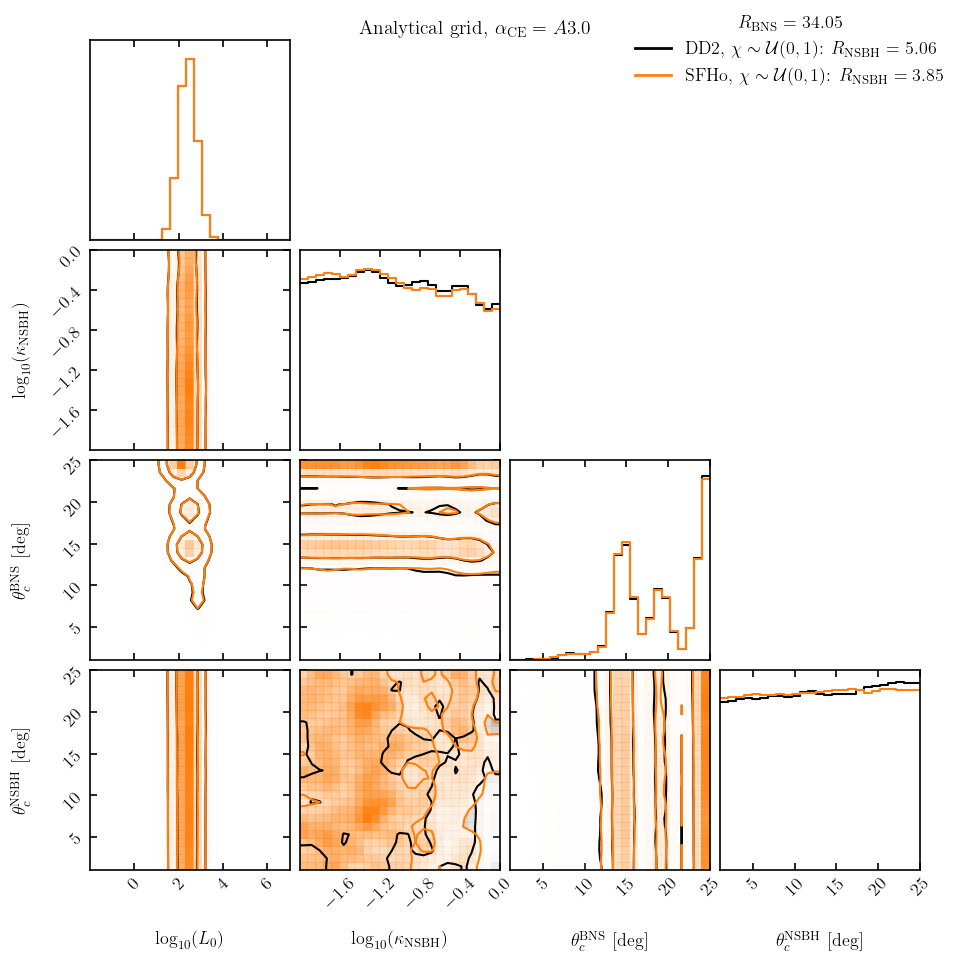

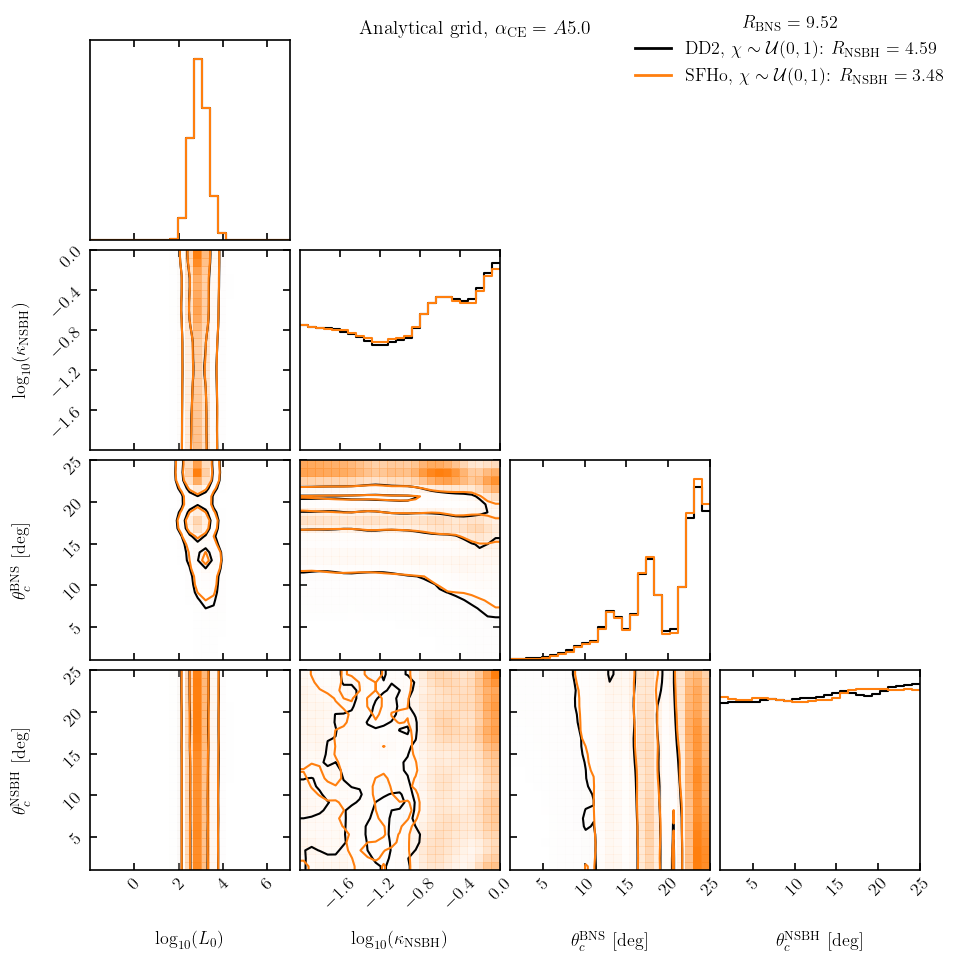

In [84]:
grid_figures = plot_corner_grid_multiples(
    POSSIBLE_ALPHA,
    grid_paths_by_series,
    population_labels=SERIES_LABELS,
    local_rate_dicts=local_rate_dicts,
    n_samples=N_GRID_DRAWS,
    seed=SEED,
)
for alpha, fig in grid_figures.items():
    fig.savefig(
        IMAGES_FOLDER / f'analytical_grid_corner_{POPULATION}_{alpha}.pdf',
        bbox_inches='tight',
    )
    plt.show()


## BNS and NSBH rate fractions

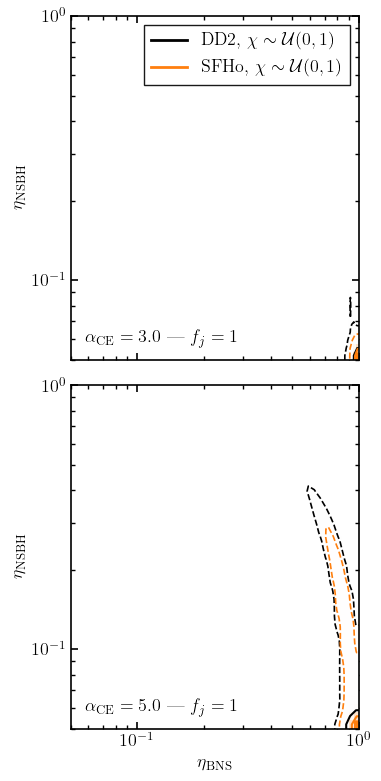

In [85]:
rate_posteriors = collect_rate_posteriors(
    grid_paths_by_series,
    fj_bns=FJ_BNS,
    n_samples=N_GRID_DRAWS,
    seed=SEED,
)

fig, axes = plot_posterior_grid(
    dictionary_of_results=rate_posteriors,
    fj_list=[FJ_BNS],
    alpha_list=POSSIBLE_ALPHA,
    nsbh_populations=NSBH_SERIES,
    population_labels=[SERIES_LABELS[series] for series in NSBH_SERIES],
    bins=40,
    levels=(0.68, 0.95),
    log_axes=True,
    minimum_fraction=5e-2,
)
fig.savefig(
    IMAGES_FOLDER / f'{POPULATION}_analytical_rate_fraction_grid.pdf',
    bbox_inches='tight',
)
plt.show()


## Compare with the fully joint seven-parameter MCMC

This optional section overlays the analytical grid with the corresponding four shared marginals from the original full MCMC. Missing full-run backends are skipped.

Loading existing directory  : Output_files/full_likelihood_alpha_A3.0_fj_1_geometric-efficiency-flat-midpoint_qcbse-NSBH-DD2-uniform-chi-0-1


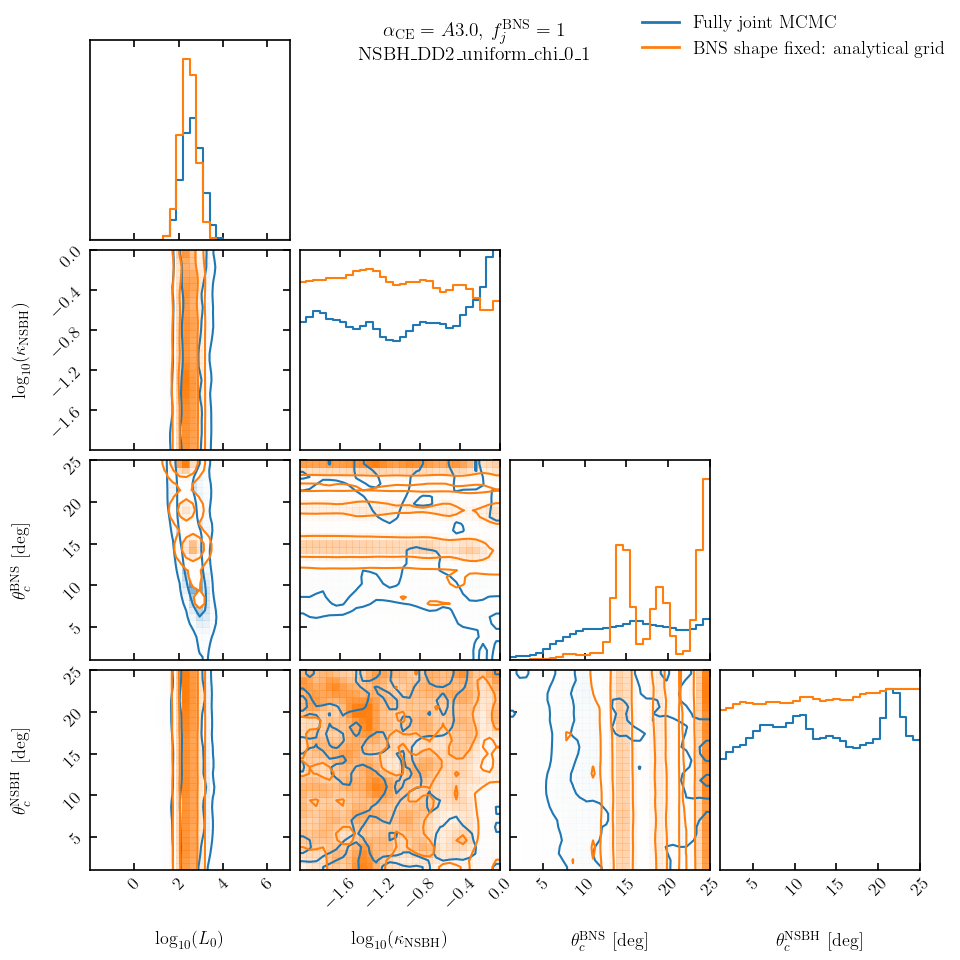

Loading existing directory  : Output_files/full_likelihood_alpha_A5.0_fj_1_geometric-efficiency-flat-midpoint_qcbse-NSBH-DD2-uniform-chi-0-1


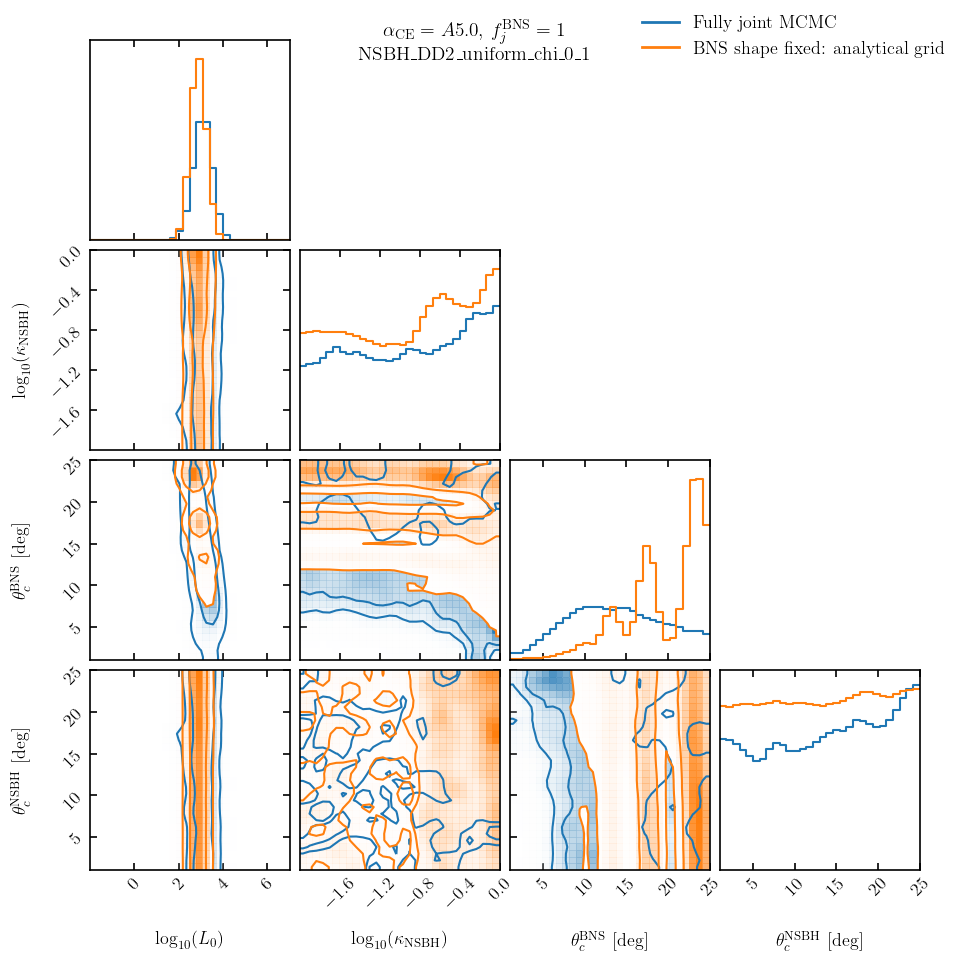

Loading existing directory  : Output_files/full_likelihood_alpha_A3.0_fj_1_geometric-efficiency-flat-midpoint_qcbse-NSBH-SFHo-uniform-chi-0-1


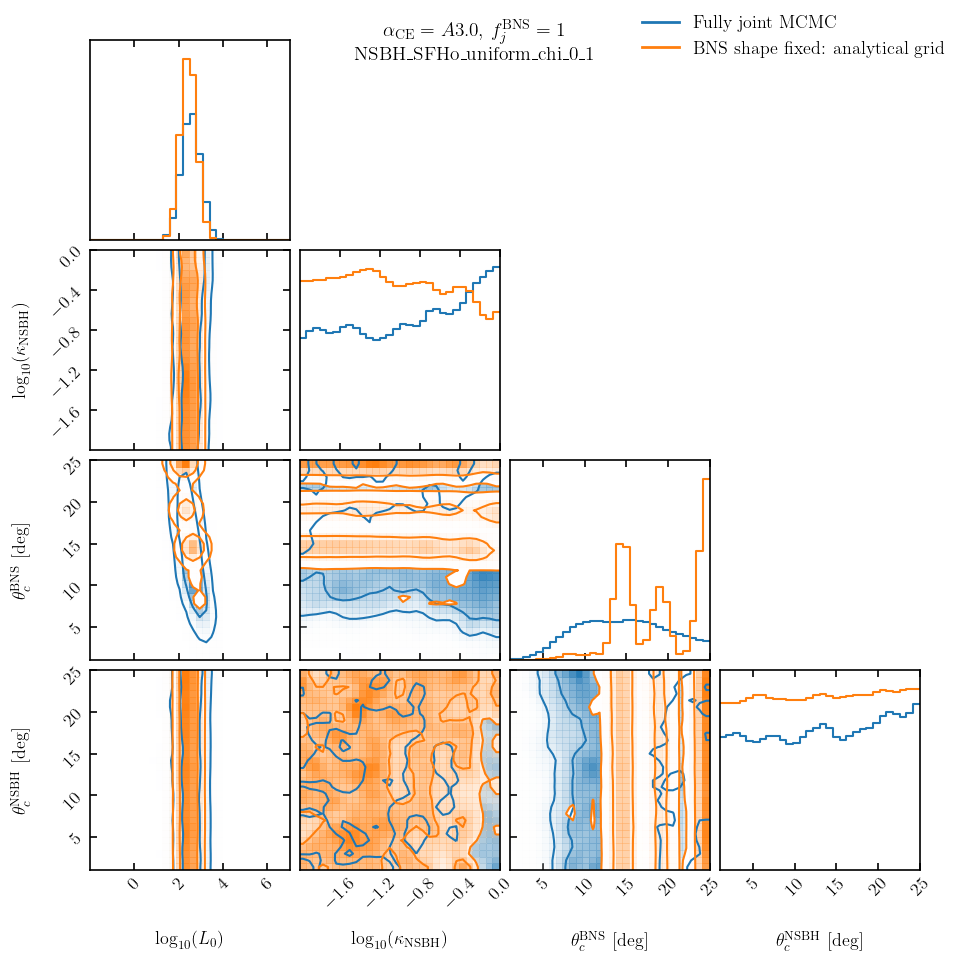

Loading existing directory  : Output_files/full_likelihood_alpha_A5.0_fj_1_geometric-efficiency-flat-midpoint_qcbse-NSBH-SFHo-uniform-chi-0-1


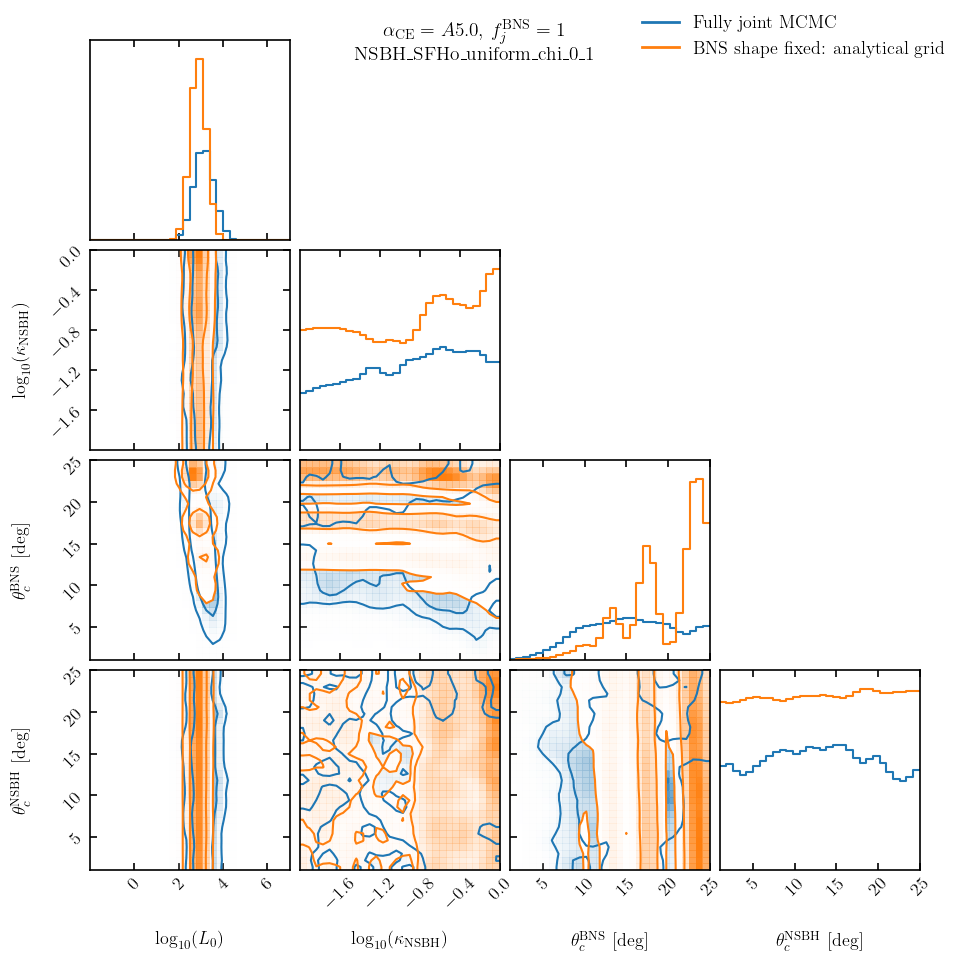

{('A3.0',
  'NSBH_DD2_uniform_chi_0_1'): {'L_L0': {'analytical_grid': array([2.1656417 , 2.44068114, 2.67787774]),
   'fully_joint_mcmc': array([2.10523009, 2.58259849, 3.15356504])}, 'log10_kappa_nsbh': {'analytical_grid': array([-1.90070538, -1.0430299 , -0.10734499]),
   'fully_joint_mcmc': array([-1.89268494, -0.92296113, -0.03821185])}, 'theta_c_bns': {'analytical_grid': array([13.12324065, 18.81047855, 24.85204848]),
   'fully_joint_mcmc': array([ 6.04682498, 15.73462651, 24.41044333])}, 'theta_c_nsbh': {'analytical_grid': array([ 2.29184479, 13.29743542, 23.86911009]),
   'fully_joint_mcmc': array([ 2.42636699, 13.12297117, 23.69322843])}},
 ('A5.0',
  'NSBH_DD2_uniform_chi_0_1'): {'L_L0': {'analytical_grid': array([2.69757417, 2.8549604 , 3.21704247]),
   'fully_joint_mcmc': array([2.55678813, 3.09031655, 3.55781125])}, 'log10_kappa_nsbh': {'analytical_grid': array([-1.88919448, -0.85098216, -0.07044049]),
   'fully_joint_mcmc': array([-1.87860196, -0.89235389, -0.06745162])}, 

In [86]:
comparison_summaries = {}

for nsbh_series in NSBH_SERIES:
    backend_label = f'{POPULATION}_{nsbh_series}'
    safe_series = nsbh_series.replace('/', '-').replace(' ', '-')

    for alpha in POSSIBLE_ALPHA:
        grid_path = grid_paths_by_series[nsbh_series][alpha]
        full_path = full_backend_path(
            alpha,
            FJ_BNS,
            GEOM_EFF_FUNC,
            backend_label,
        )
        if not Path(full_path).is_file():
            print(f'Skipping missing full-run backend: {full_path}')
            continue

        comparison_summaries[(alpha, nsbh_series)] = summarize_grid_vs_full(
            grid_path,
            full_path,
            n_samples=N_GRID_DRAWS,
            seed=SEED,
            burn_frac=BURN_FRAC,
            thin=THIN,
        )
        fig = plot_grid_vs_full(
            grid_path,
            full_path,
            n_samples=N_GRID_DRAWS,
            seed=SEED,
            burn_frac=BURN_FRAC,
            thin=THIN,
        )
        fig.suptitle(
            rf'$\alpha_{{\rm CE}}={alpha}$, $f_j^{{\rm BNS}}={FJ_BNS:g}$'
            + '\n'
            + nsbh_series,
            fontsize=14,
        )
        fig.savefig(
            IMAGES_FOLDER
            / f'analytical_vs_full_{POPULATION}_{safe_series}_{alpha}_{FJ_BNS:g}.pdf',
            bbox_inches='tight',
        )
        plt.show()

comparison_summaries

### Interpretation

The analytical-grid result conditions on one BNS-only point estimate, so it will generally be narrower than the fully joint posterior. A shift in the medians signals that the BNS-only optimum is not representative of the joint posterior; similar medians with narrower grid contours mainly indicate the uncertainty lost by fixing $(A,\mu_E,\sigma_E)$.

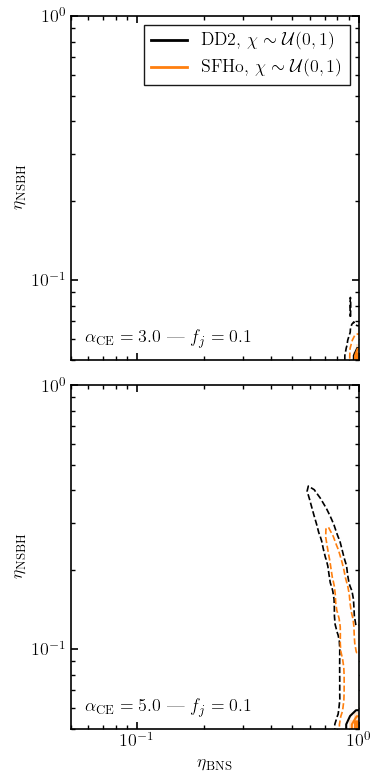

In [ ]:
fj_plot_BNS = 0.1 # 1.0

rate_posteriors_01 = collect_rate_posteriors(
    grid_paths_by_series,
    fj_bns=fj_plot_BNS,
    n_samples=N_GRID_DRAWS,
    seed=SEED,
)

fig, axes = plot_posterior_grid(
    dictionary_of_results=rate_posteriors,
    fj_list=[fj_plot_BNS],
    alpha_list=POSSIBLE_ALPHA,
    nsbh_populations=NSBH_SERIES,
    population_labels=[SERIES_LABELS[series] for series in NSBH_SERIES],
    bins=40,
    levels=(0.68, 0.95),
    log_axes=True,
    minimum_fraction=5e-2,
)


fig.savefig(
    IMAGES_FOLDER / f'{POPULATION}_analytical_rate_fraction_grid_{fj_plot_BNS:g}.pdf',
    bbox_inches='tight',
)
plt.show()

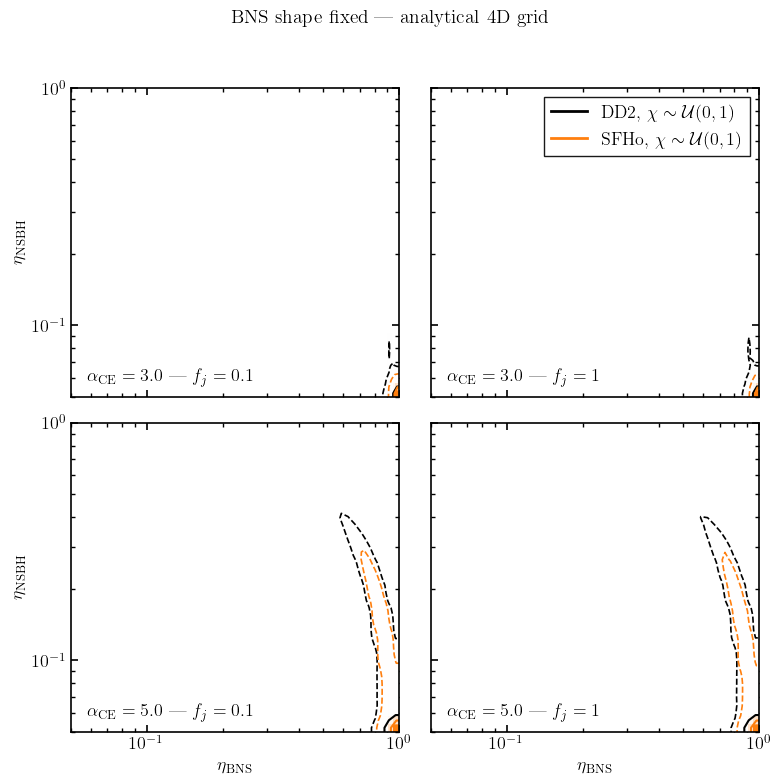

Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
BNS: R(z=0.01)=34.05 Gpc^-3 yr^-1; all-sky rate=2.616e+04 yr^-1; MC sample=1
NSBH_DD2_uniform_chi_0_1: R(z=0.01)=5.06 Gpc^-3 yr^-1; all-sky rate=7.750e+03 yr^-1; MC sample=1
Loading existing directory  : Output_files/full_likelihood_alpha_A3.0_fj_0.1_geometric-efficiency-flat-midpoint_qcbse-NSBH-DD2-uniform-chi-0-1
Loading existing directory  : Output_files/full_likelihood_alpha_A3.0_fj_0.1_geometric-efficiency-flat-midpoint_qcbse-NSBH-SFHo-uniform-chi-0-1
Loading existing directory  : Output_files/full_likelihood_alpha_A3.0_fj_1_geometric-efficiency-flat-midpoint_qcbse-NSBH-DD2-uniform-chi-0-1
Loading existing directory  : Output_files/full_likelihood_alpha_A3.0_fj_1_geometric-efficiency-flat-midpoint_qcbse-NSBH-SFHo-uniform-chi-0-1
Loading existing directory  : Output_files/full_likelihood_alpha_A5.0_fj_0.1_

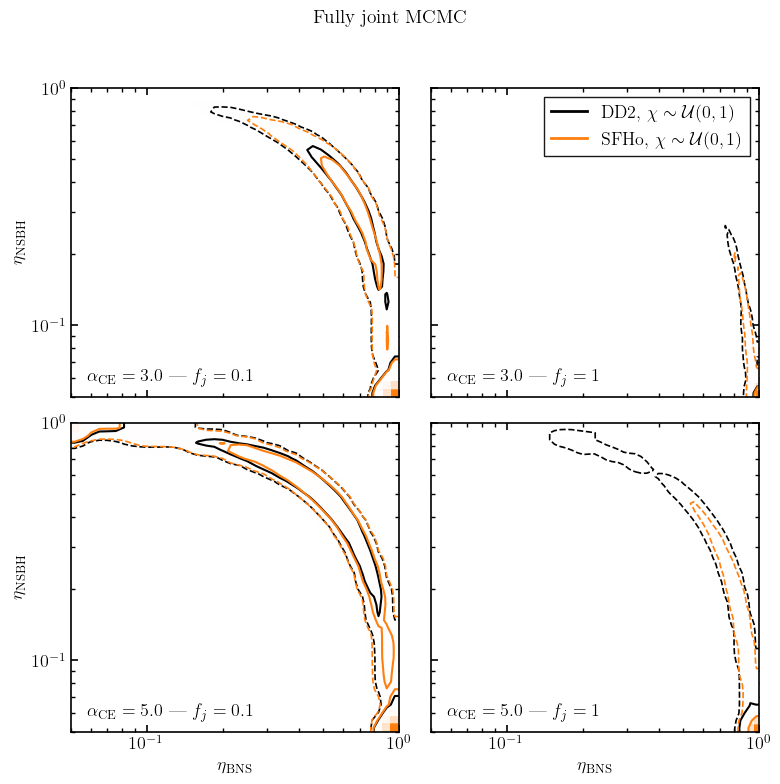

In [ ]:
# After running the analytical grid with fj_plot_BNS = 0.1
grid_paths_01 = {
    series: dict(paths)
    for series, paths in grid_paths_by_series.items()
}

# After rerunning it with fj_plot_BNS = 1.0
grid_paths_10 = {
    series: dict(paths)
    for series, paths in grid_paths_by_series.items()
}

from mcmc_runny import (
    collect_rate_posteriors as collect_full_rate_posteriors,
)

FJ_PLOT = [0.1, 1.0]

grid_paths_by_fj = {
    0.1: grid_paths_01,
    1.0: grid_paths_10,
}

# --------------------------------------------------
# 1. Analytical 4D-grid fractions
# --------------------------------------------------

analytical_rates = {}

for index, fj_bns in enumerate(FJ_PLOT):
    analytical_rates.update(
        collect_rate_posteriors(
            grid_paths_by_fj[fj_bns],
            fj_bns=fj_bns,
            n_samples=N_GRID_DRAWS,
            seed=SEED + index,
        )
    )

fig_4d, axes_4d = plot_posterior_grid(
    dictionary_of_results=analytical_rates,
    fj_list=FJ_PLOT,
    alpha_list=POSSIBLE_ALPHA,
    nsbh_populations=NSBH_SERIES,
    population_labels=[
        SERIES_LABELS[series]
        for series in NSBH_SERIES
    ],
    bins=40,
    levels=(0.68, 0.95),
    log_axes=True,
    minimum_fraction=5e-2,
)

fig_4d.suptitle(
    "BNS shape fixed — analytical 4D grid",
    fontsize=14,
)
fig_4d.tight_layout(rect=(0, 0, 1, 0.96))

fig_4d.savefig(
    IMAGES_FOLDER
    / f"{POPULATION}_analytical_fractions_fj_0.1_1.0.pdf",
    bbox_inches="tight",
)

plt.show()


# --------------------------------------------------
# 2. Fully joint MCMC fractions
# --------------------------------------------------

full_rates = collect_full_rate_posteriors(
    alphas=POSSIBLE_ALPHA,
    fj_list=FJ_PLOT,
    population=POPULATION,
    nsbh_series=NSBH_SERIES,
    geom_eff_func=GEOM_EFF_FUNC,
    datafiles=DATAFILES,
    burn_frac=BURN_FRAC,
    thin=THIN,
)

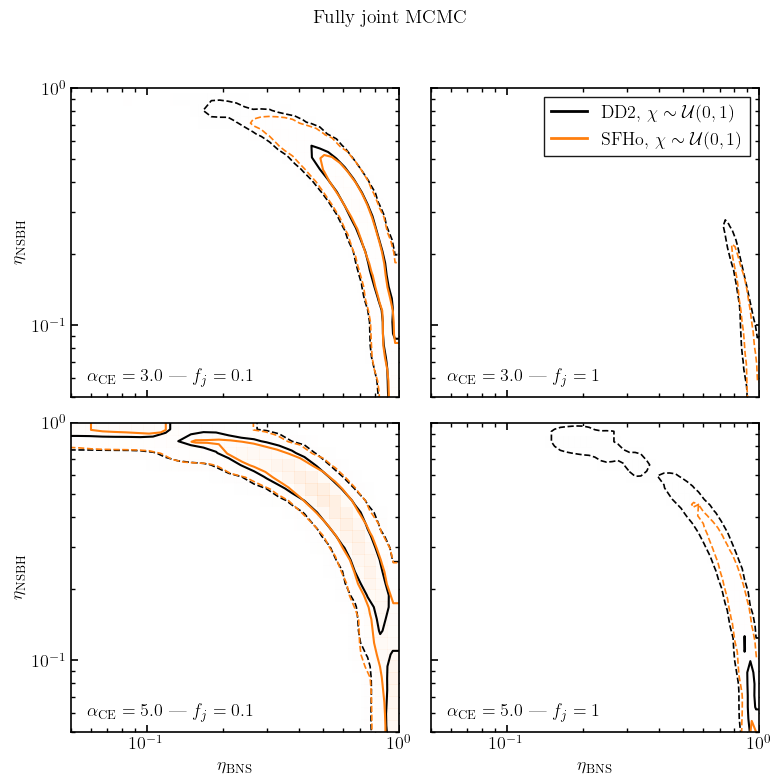

In [93]:

fig_full, axes_full = plot_posterior_grid(
    dictionary_of_results=full_rates,
    fj_list=FJ_PLOT,
    alpha_list=POSSIBLE_ALPHA,
    nsbh_populations=NSBH_SERIES,
    population_labels=[
        SERIES_LABELS[series]
        for series in NSBH_SERIES
    ],
    bins=40,
    levels=(0.68, 0.95),
    log_axes=True
)

fig_full.suptitle(
    "Fully joint MCMC",
    fontsize=14,
)
fig_full.tight_layout(rect=(0, 0, 1, 0.96))

fig_full.savefig(
    IMAGES_FOLDER
    / f"{POPULATION}_full_fractions_fj_0.1_1.0.pdf",
    bbox_inches="tight",
)

plt.show()

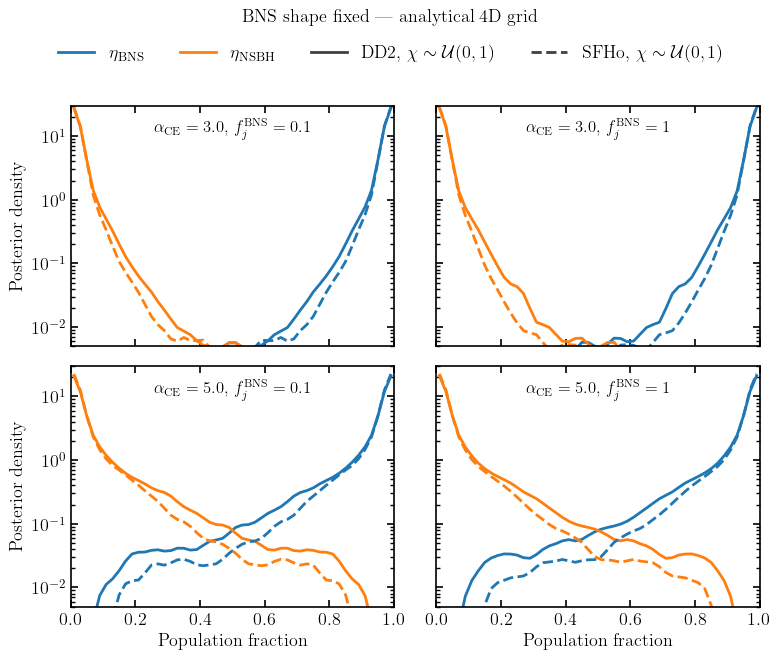

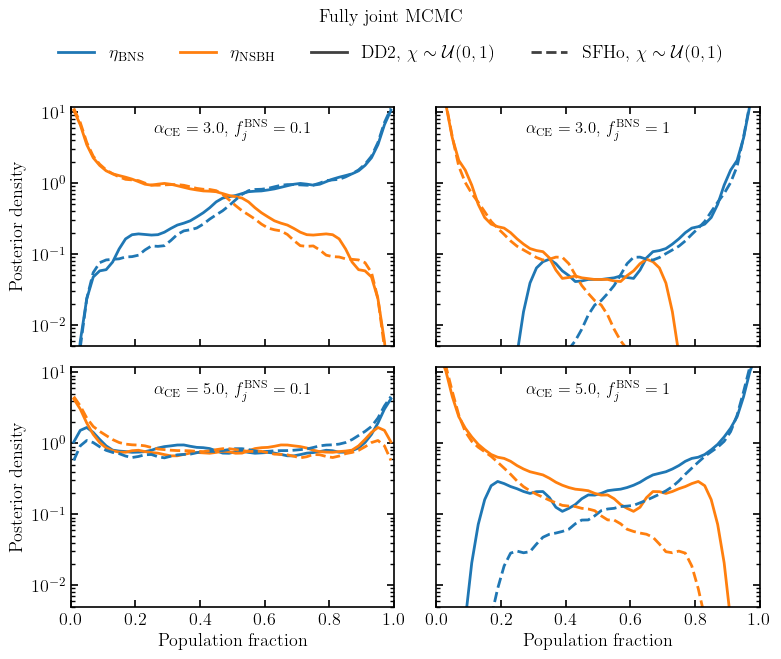

In [100]:
from scipy.ndimage import gaussian_filter1d

def plot_fraction_1d(
    dictionary_of_results,
    fj_list,
    alpha_list,
    nsbh_populations,
    population_labels=None,
    bins=50,
    smooth_sigma=1.0,
    swap_axes=False,
):
    """
    Plot 1D posterior densities of eta_BNS and eta_NSBH.

    Colors:
        blue   = BNS
        orange = NSBH

    Line styles:
        solid  = first EOS
        dashed = second EOS
    """
    if population_labels is None:
        population_labels = list(nsbh_populations)

    row_values = fj_list if swap_axes else alpha_list
    col_values = alpha_list if swap_axes else fj_list

    rows = len(row_values)
    cols = len(col_values)

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(4 * cols, 3.2 * rows),
        squeeze=False,
        sharex=True,
        sharey=True,
    )

    component_colors = {
        "BNS": "C0",
        "NSBH": "C1",
    }

    eos_linestyles = ["-", "--", ":", "-."]
    bin_edges = np.linspace(0.0, 1.0, bins + 1)
    bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    for row_index, row_value in enumerate(row_values):
        for col_index, col_value in enumerate(col_values):
            alpha = col_value if swap_axes else row_value
            fj_bns = row_value if swap_axes else col_value
            ax = axes[row_index, col_index]

            for eos_index, population in enumerate(nsbh_populations):
                entry = dictionary_of_results[
                    (float(fj_bns), alpha, population)
                ]

                rate_bns = np.asarray(entry["R_BNS"], dtype=float)
                rate_nsbh = np.asarray(entry["R_NSBH"], dtype=float)

                total_rate = rate_bns + rate_nsbh
                valid = (
                    np.isfinite(rate_bns)
                    & np.isfinite(rate_nsbh)
                    & np.isfinite(total_rate)
                    & (total_rate > 0)
                )

                eta_bns = rate_bns[valid] / total_rate[valid]

                # Explicitly use complementarity.
                eta_nsbh = 1.0 - eta_bns

                linestyle = eos_linestyles[
                    eos_index % len(eos_linestyles)
                ]

                for component, samples in {
                    "BNS": eta_bns,
                    "NSBH": eta_nsbh,
                }.items():
                    density, _ = np.histogram(
                        samples,
                        bins=bin_edges,
                        density=True,
                    )

                    if smooth_sigma:
                        density = gaussian_filter1d(
                            density,
                            smooth_sigma,
                        )

                    ax.plot(
                        bin_centres,
                        density,
                        color=component_colors[component],
                        linestyle=linestyle,
                        linewidth=2,
                    )

            alpha_label = (
                str(alpha)[1:]
                if str(alpha).startswith("A")
                else str(alpha)
            )

            #ax.set_title(
            #    rf"$\alpha_{{\rm CE}}={alpha_label}$"
            #    rf", $f_j^{{\rm BNS}}={float(fj_bns):g}$"
            #) # as text right in the middle within fram
            ax.text(
                0.5,
                0.9,
                rf"$\alpha_{{\rm CE}}={alpha_label}$"
                rf", $f_j^{{\rm BNS}}={float(fj_bns):g}$",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=12,
            )
            ax.set_xlim(0.0, 1.0)
            ax.set_ylim(bottom=5e-3)
            ax.set_yscale("log")

            if row_index == rows - 1:
                ax.set_xlabel("Population fraction")

            if col_index == 0:
                ax.set_ylabel("Posterior density")

    component_handles = [
        plt.Line2D(
            [0],
            [0],
            color=component_colors["BNS"],
            linewidth=2,
            label=r"$\eta_{\rm BNS}$",
        ),
        plt.Line2D(
            [0],
            [0],
            color=component_colors["NSBH"],
            linewidth=2,
            label=r"$\eta_{\rm NSBH}$",
        ),
    ]

    eos_handles = [
        plt.Line2D(
            [0],
            [0],
            color="0.25",
            linestyle=eos_linestyles[index],
            linewidth=2,
            label=label,
        )
        for index, label in enumerate(population_labels)
    ]

    fig.legend(
        handles=component_handles + eos_handles,
        loc="upper center",
        ncol=2 + len(eos_handles),
        frameon=False,
        bbox_to_anchor=(0.5, 1.0),
    )

    fig.tight_layout(rect=(0, 0, 1, 0.91))
    return fig, axes

common_1d_kwargs = {
    "fj_list": FJ_PLOT,
    "alpha_list": POSSIBLE_ALPHA,
    "nsbh_populations": NSBH_SERIES,
    "population_labels": [
        SERIES_LABELS[series]
        for series in NSBH_SERIES
    ],
    "bins": 50,
    "smooth_sigma": 1.0,
}


# Analytical 4D grids
fig_1d_4d, axes_1d_4d = plot_fraction_1d(
    analytical_rates,
    **common_1d_kwargs,
)

fig_1d_4d.suptitle(
    "BNS shape fixed — analytical 4D grid",
    y=1.03,
)

fig_1d_4d.savefig(
    IMAGES_FOLDER
    / f"{POPULATION}_analytical_fraction_1d_fj_0.1_1.0.pdf",
    bbox_inches="tight",
)

plt.show()


# Fully joint MCMC
fig_1d_full, axes_1d_full = plot_fraction_1d(
    full_rates,
    **common_1d_kwargs,
)

fig_1d_full.suptitle(
    "Fully joint MCMC",
    y=1.03,
)

fig_1d_full.savefig(
    IMAGES_FOLDER
    / f"{POPULATION}_full_fraction_1d_fj_0.1_1.0.pdf",
    bbox_inches="tight",
)

plt.show()